# Worksheet 2: Root finding
## - 23MS121 
## - Manish Behera

### Q1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

For Q1 we need
$$I=\int_0^{\infty} f(x)\,dx,\qquad f(x)=\frac{x^3}{e^x-1}.$$
Choose a trial (importance) function
$$t(x)=\frac{1}{b+(x-x_0)^2},\quad x\ge 0.$$

### Step 1: Choose $x_0$ and $b$ (intuitively)
- Choose $x_0$ near the peak of $f(x)$ so sampling focuses where contribution is largest.
- For $f(x)=x^3/(e^x-1)$, the peak is near $x\approx 2.82$, so take $x_0\approx 2.8$.
- Choose $b$ to control width:
  - smaller $b$ = sharper peak,
  - larger $b$ = broader sampling.
- Start with $b\in[0.5,2]$ and tune by checking Monte Carlo error. Here we use $b=1$.

### Step 2: Normalize the trial function on $[0,\infty)$
Define
$$p(x)=A\,t(x)=\frac{A}{b+(x-x_0)^2},\qquad \int_0^{\infty}p(x)dx=1.$$
Compute
$$\int_0^{\infty}\frac{dx}{b+(x-x_0)^2}
=\frac{1}{\sqrt b}\left(\frac{\pi}{2}+\tan^{-1}\frac{x_0}{\sqrt b}\right).$$
Hence
$$A=\frac{\sqrt b}{\frac{\pi}{2}+\tan^{-1}(x_0/\sqrt b)}.$$

### Step 3: Build CDF $y(x)$
$$y(x)=\int_0^x p(z)dz
=\frac{A}{\sqrt b}\left[\tan^{-1}\left(\frac{x-x_0}{\sqrt b}\right)+\tan^{-1}\left(\frac{x_0}{\sqrt b}\right)\right],$$
so $y\in[0,1)$.

### Step 4: Invert to get $x(y)$
From the above,
$$\tan^{-1}\left(\frac{x-x_0}{\sqrt b}\right)
=\frac{\sqrt b}{A}y-\tan^{-1}\left(\frac{x_0}{\sqrt b}\right),$$
therefore
$$x(y)=x_0+\sqrt b\tan\left(\frac{\sqrt b}{A}y-\tan^{-1}\left(\frac{x_0}{\sqrt b}\right)\right).$$

### Step 5: Convert integral to uniform-$y$ form
$$I=\int_0^{\infty} f(x)dx=\int_0^1 \frac{f(x(y))}{p(x(y))}\,dy
\equiv \int_0^1 g(y)\,dy,$$
with
$$g(y)=\frac{f(x(y))}{p(x(y))}. $$
Then Monte Carlo estimate is
$$ I\approx \frac1N\sum_{i=1}^N g(y_i),\quad y_i\sim U(0,1). $$

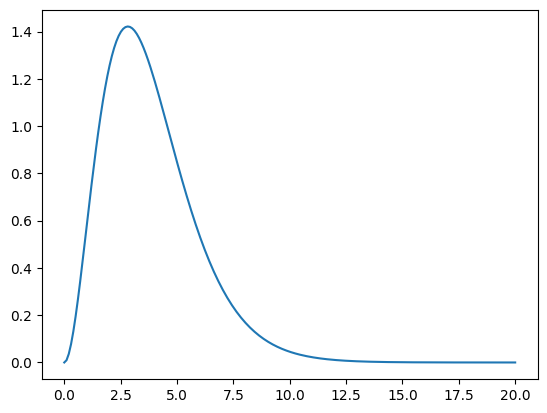

In [3]:
def f(x):
    if x <= 0:
        return 0
    return x**3 / (np.exp(x) - 1)

xs = np.linspace(0.0, 20.0, num=200)
ys = [f(x) for x in xs]
plt.plot(xs, ys);


In [4]:
# parameters 
x0 = 2.8 #around the peak of the function
b = 1.0


def w(x, b, x0):
    return 1.0 / (b + (x - x0)**2)

# def y(x) and then invert it to get x(y).
# y(x) = integral from 0 to x of 1/(b + (z-x0)^2) dz

#Normalize w(x) to get a valid PDF
def norm_const(b, x0):
    return (1/np.sqrt(b)) * (np.arctan((1-x0)/np.sqrt(b)) - np.arctan(-x0/np.sqrt(b)))

# Now the CDF y(x) = int w(z) dz from 0 to x
def cdf_y(x, b, x0):
    return (1/np.sqrt(b)) * (np.arctan((x-x0)/np.sqrt(b)) - np.arctan(-x0/np.sqrt(b)))*norm_const(b, x0)

# And the inverse CDF x(y) = solve for x in terms of y
def inv_cdf_x(y, b, x0):
    return x0 + np.sqrt(b) * np.tan(y * np.sqrt(b)/norm_const(b, x0) + np.arctan(-x0/np.sqrt(b)))

# The new function to integrate over a uniform distribution y
def g(y, b, x0): # g(y) = f(x(y)) / w(x(y))
    x = inv_cdf_x(y, b, x0)
    return f(x) / w(x, b, x0)

# Monte Carlo integration
def mc_integration(n_samples, b, x0):
    ys = np.random.rand(n_samples)
    integral_sum = 0
    for y in ys:
        integral_sum += g(y, b, x0)
    return integral_sum / n_samples

def MC_eval_g(n):
    store = 0.0
    for i in range(n):
        y = np.random.rand() #integrate over [0,1] since w(x) is a valid PDF over [0,1]
        store += g(y, b, x0)
    return store/n

def MC_eval_f(n):
    store = 0.0
    for i in range(n):
        x = np.random.rand() #integrate over [0,1]
        store += f(x)
    return store/n

# Perform the integration
n_samples = 1000000
integral_value = mc_integration(n_samples, b, x0)
intg = MC_eval_g(n_samples)

print(f"Number of samples: {n_samples}")
print(f"Calculated integral: {integral_value}")
print(f"Calculated integral (alternative method): {intg}")
print(f"Calculated integral (naive method): {MC_eval_f(n_samples)}")


C:\Users\mbsci\AppData\Local\Temp\ipykernel_18608\1720802359.py:4: RuntimeWarning: overflow encountered in exp
  return x**3 / (np.exp(x) - 1)


Number of samples: 1000000
Calculated integral: 2.1323369529473126
Calculated integral (alternative method): 2.1318362268093716
Calculated integral (naive method): 0.22505891710805498


### Q2

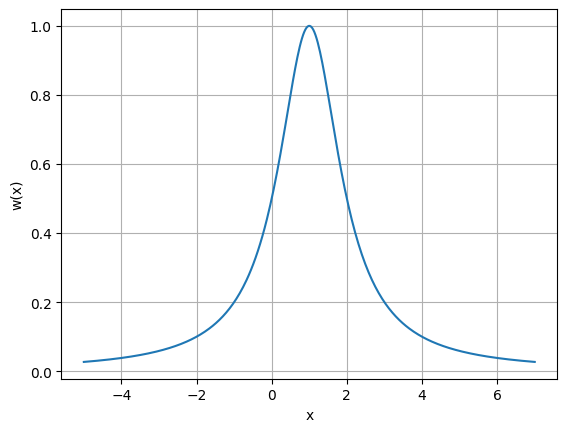

In [5]:
# (a) Plot the distribution
def w(x):
    return 1 / (1 + (x - 1)**2)

x_vals = np.linspace(-5, 7, 400)
y_vals = w(x_vals)

plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("w(x)")
plt.grid(True)
plt.show()


In [6]:
# (b) Metropolis 
x0 = 0.5
n = 1000000 #1e6
stepsize = 1.0 # As per instruction "maximum step size 1"

store = np.zeros(n)
for i in range(n):
    store[i] = x0
    dx = stepsize * (np.random.rand() - 0.5) * 2 #[-1, 1]
    x1 = x0 + dx
    r = w(x1) / w(x0)
    # Accept the step with a probability a = min(1, r)
    if r >= 1:
        x0 = x1
    else:
        p = np.random.rand()
        if p <= r:
            x0 = x1


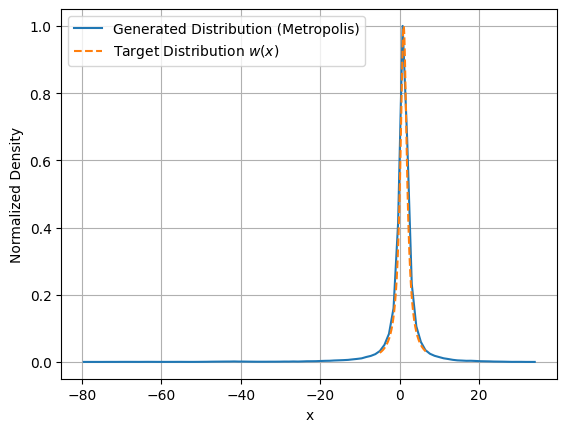

In [7]:
# Target distribution
x_w = np.linspace(-5, 7, 400)
y_w = w(x_w)
y_w_normalized = y_w / np.max(y_w)

# Generated data histogram
values, edges = np.histogram(store, bins=100, density=True)
midpoints = (edges[:-1] + edges[1:]) / 2

# Normalize generated data
values_normalized = values / np.max(values)

plt.plot(midpoints, values_normalized, label='Generated Distribution (Metropolis)')
plt.plot(x_w, y_w_normalized, label='Target Distribution $w(x)$', linestyle='--')
plt.xlabel("x")
plt.ylabel("Normalized Density")
plt.grid(True)
plt.legend()
plt.show()

note how the generated distribution stays close to the peak of w(x) and avoids the tails.

# endsem 25 Q5

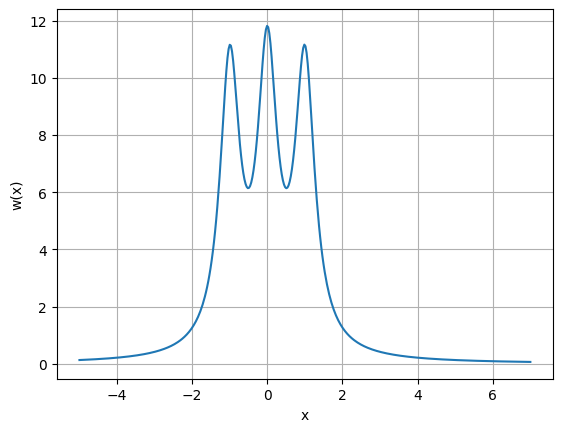

In [23]:
# (a) Plot the distribution
def w(x):
    return 1 / (0.1 + (1+x)**2) + 1/(0.1 + x**2) + 1/(0.1 + (1-x)**2)

x_vals = np.linspace(-5, 7, 400)
y_vals = w(x_vals)

plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("w(x)")
plt.grid(True)
plt.show()

In [32]:
# (b) Metropolis 
x0 = 0.5
n = 1000000 #1e6
stepsize = 1 # As per instruction "maximum step size 1"

store = np.zeros(n)
for i in range(n):
    dx = stepsize * (np.random.rand() - 0.5) * 2 #[-1, 1]
    x1 = x0 + dx
    r = w(x1) / w(x0)
    A = min(1,r)
    # Accept the step with probability A
    if np.random.rand() <= A:
        x0 = x1
    # Store the (accepted or retained) current state
    store[i] = x0



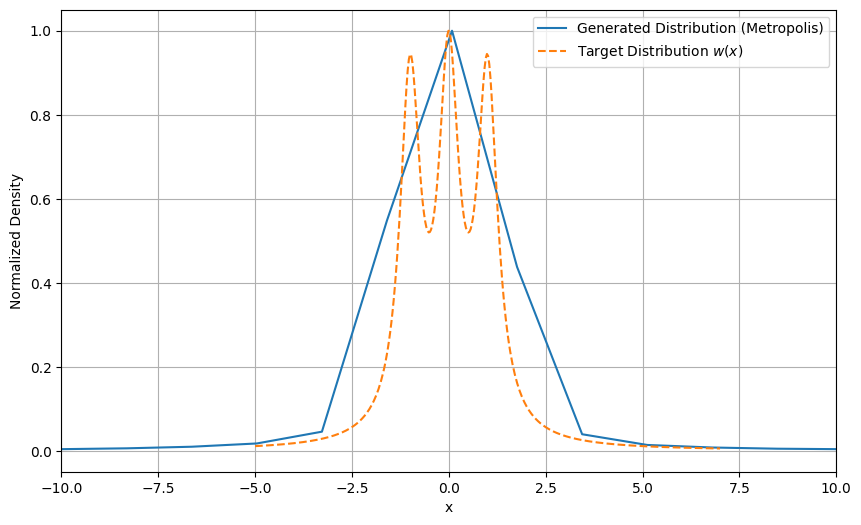

In [33]:
# Target distribution
x_w = np.linspace(-5, 7, 400)
y_w = w(x_w)
y_w_normalized = y_w / np.max(y_w)

# Generated data histogram
values, edges = np.histogram(store, bins=100, density=True)
midpoints = (edges[:-1] + edges[1:]) / 2

# Normalize generated data
values_normalized = values / np.max(values)
plt.figure(figsize=(10, 6))
plt.xlim(-10, 10)
plt.plot(midpoints, values_normalized, label='Generated Distribution (Metropolis)')
plt.plot(x_w, y_w_normalized, label='Target Distribution $w(x)$', linestyle='--')
plt.xlabel("x")
plt.ylabel("Normalized Density")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
import numpy as np

def w(x):
    return 1 / (0.1 + (1+x)**2) + 1/(0.1 + x**2) + 1/(0.1 + (1-x)**2)

def acceptance_rate(n_steps=1000, step_size=1.0, x0=0.5):
    x = x0
    accepted = 0
    for _ in range(n_steps):
        dx = np.random.uniform(-step_size, step_size)
        x_new = x + dx

        r = w(x_new) / w(x)
        A = min(1.0, r)

        if np.random.rand() <= A:
            x = x_new
            accepted += 1
    return accepted / n_steps

In [22]:
target = 0.50
tol = 0.02
low, high = 0.01, 10.0

for _ in range(20):
    step = 0.5 * (low + high)
    rate = acceptance_rate(n_steps=1000, step_size=step, x0=0.5)
    print(f"step={step:.4f}, acceptance={rate:.3f}")

    if abs(rate - target) < tol:
        break

    # Larger step -> usually lower acceptance
    if rate > target:
        low = step
    else:
        high = step

print(f"\nChosen step size ~ {step:.4f} with acceptance ~ {rate:.3f}")

step=5.0050, acceptance=0.358
step=2.5075, acceptance=0.647
step=3.7562, acceptance=0.429
step=3.1319, acceptance=0.522
step=3.4441, acceptance=0.480
step=3.2880, acceptance=0.528
step=3.3660, acceptance=0.490

Chosen step size ~ 3.3660 with acceptance ~ 0.490
